# Chunking retrieval evaluation

Compare the 350/50, 250/40, and 150/30 chunk configurations using the same questions and TF–IDF retrieval baseline. The notebook excludes Q46–Q52, Q58, and Q60.

**Metric definition:** Recall@k is the fraction of unique gold source IDs represented by the top-k chunks, averaged across scored questions. MRR is the reciprocal rank of the first chunk whose `source_id` matches any gold source. Rows without gold sources are reported but excluded from retrieval metrics.

In [1]:
from pathlib import Path
import json
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel

pd.set_option('display.max_colwidth', 120)
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists() and (PROJECT_ROOT.parent / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
PROJECT_ROOT

WindowsPath('C:/Users/spide/Desktop/Project Folder - Govtech')

In [2]:
QUESTIONS_PATH = PROJECT_ROOT / 'evaluation_questions' / 'benchmark_60_with_draft_gold_answers.xlsx'
CONFIGS = {
    '350w_50o': PROJECT_ROOT / 'data/experiments/350w_50o/chunks.jsonl',
    '250w_40o': PROJECT_ROOT / 'data/experiments/250w_40o/chunks.jsonl',
    '150w_30o': PROJECT_ROOT / 'data/experiments/150w_30o/chunks.jsonl',
}
EXCLUDED_NUMBERS = {46, 47, 48, 49, 50, 51, 52, 58, 60}
TOP_KS = (1, 3, 5)

def question_number(value):
    match = re.search(r'\d+', str(value))
    return int(match.group()) if match else None

def parse_gold_sources(value):
    if pd.isna(value) or not str(value).strip():
        return set()
    return {part.strip() for part in re.split(r'[,;|+]', str(value)) if part.strip()}

questions_all = pd.read_excel(QUESTIONS_PATH)
questions_all['question_number'] = questions_all['question_id'].map(question_number)
questions_all['gold_sources'] = questions_all['gold_source_ids'].map(parse_gold_sources)
questions = questions_all.loc[~questions_all['question_number'].isin(EXCLUDED_NUMBERS)].copy()
scored_questions = questions.loc[questions['gold_sources'].map(bool)].copy()

print(f'Workbook rows: {len(questions_all)}')
print(f'Excluded rows: {len(questions_all) - len(questions)}')
print(f'Remaining rows: {len(questions)}')
print(f'Scored rows with gold sources: {len(scored_questions)}')
print(f'Rows without gold sources (not scored): {len(questions) - len(scored_questions)}')
questions.groupby(['category', 'expected_behavior'], dropna=False).size().rename('questions').to_frame()

Workbook rows: 60
Excluded rows: 9
Remaining rows: 51
Scored rows with gold sources: 51
Rows without gold sources (not scored): 0


,,questions
category,expected_behavior,
adversarial_misleading,correct_false_premise_or_qualify,4
conditional,answer_or_qualified,10
direct_answerable,answer,15
multi_hop,answer,10
partially_answerable,qualified_answer_or_abstain_on_missing_personal_inputs,10
temporal,answer_or_abstain_based_on_effective_date,2


In [3]:
def load_chunks(path):
    records = [json.loads(line) for line in path.read_text(encoding='utf-8').splitlines() if line.strip()]
    return pd.DataFrame([{
        'chunk_id': record['chunk_id'],
        'text': record['text'],
        'source_id': record['metadata']['source_id'],
        'title': record['metadata']['title'],
        'heading_path': ' > '.join(record['metadata'].get('heading_path', [])),
    } for record in records])

corpora = {name: load_chunks(path) for name, path in CONFIGS.items()}
pd.DataFrame([
    {'configuration': name, 'chunks': len(frame),
     'mean_words': frame['text'].str.split().str.len().mean(),
     'median_words': frame['text'].str.split().str.len().median()}
    for name, frame in corpora.items()
]).set_index('configuration').round(1)

,chunks,mean_words,median_words
configuration,,,
350w_50o,280,234.3,313.0
250w_40o,364,186.0,250.0
150w_30o,567,126.5,150.0


## Retrieve and score

Each configuration fits its own TF–IDF index using identical vectorizer settings. Ranking is at chunk level; repeated chunks from one source still occupy separate ranks, matching a normal vector-search result list.

In [4]:
def evaluate_configuration(name, chunks, eval_questions, top_ks=TOP_KS):
    vectorizer = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, min_df=1)
    chunk_matrix = vectorizer.fit_transform(chunks['text'])
    query_matrix = vectorizer.transform(eval_questions['question'])
    scores = linear_kernel(query_matrix, chunk_matrix)
    max_k = max(top_ks)
    rows = []

    for query_pos, (_, question) in enumerate(eval_questions.iterrows()):
        ranking = np.argsort(-scores[query_pos], kind='stable')
        ranked = chunks.iloc[ranking].reset_index(drop=True)
        gold = question['gold_sources']
        relevant_positions = [
            rank for rank, source_id in enumerate(ranked['source_id'], start=1)
            if source_id in gold
        ]
        row = {
            'configuration': name,
            'question_id': question['question_id'],
            'category': question['category'],
            'question': question['question'],
            'gold_sources': ', '.join(sorted(gold)),
            'mrr': 1 / relevant_positions[0] if relevant_positions else 0.0,
            'first_relevant_rank': relevant_positions[0] if relevant_positions else np.nan,
            'top5_sources': ', '.join(ranked.head(max_k)['source_id']),
            'top5_chunk_ids': ', '.join(ranked.head(max_k)['chunk_id']),
        }
        for k in top_ks:
            retrieved_sources = set(ranked.head(k)['source_id'])
            row[f'recall@{k}'] = len(gold & retrieved_sources) / len(gold)
        rows.append(row)
    return pd.DataFrame(rows)

details = pd.concat([
    evaluate_configuration(name, chunks, scored_questions)
    for name, chunks in corpora.items()
], ignore_index=True)
metric_columns = [f'recall@{k}' for k in TOP_KS] + ['mrr']
summary = details.groupby('configuration')[metric_columns].mean().sort_values('mrr', ascending=False)
summary.style.format('{:.3f}').highlight_max(axis=0, color='#c6efce')

,recall@1,recall@3,recall@5,mrr
configuration,,,,
350w_50o,0.441,0.632,0.805,0.703
250w_40o,0.402,0.602,0.746,0.669
150w_30o,0.370,0.641,0.684,0.640


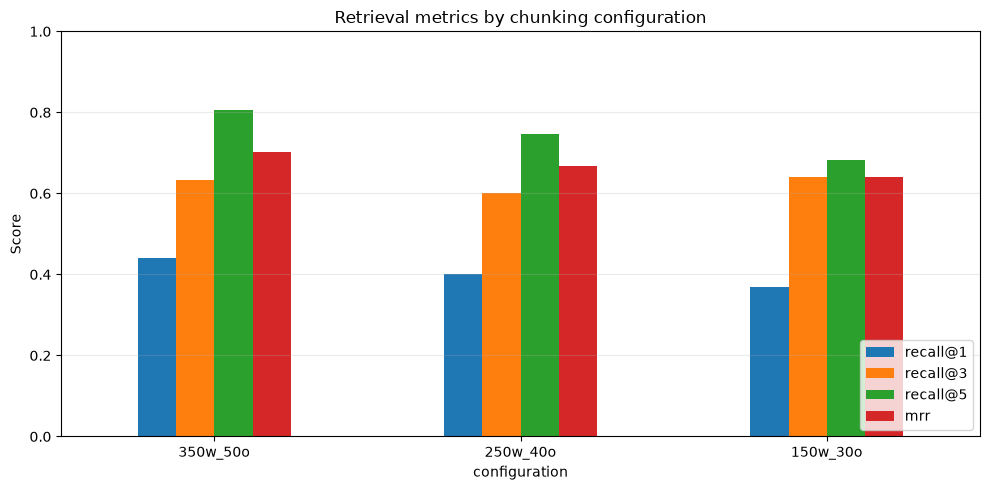

In [5]:
ax = summary.plot(kind='bar', figsize=(10, 5), ylim=(0, 1), rot=0)
ax.set_title('Retrieval metrics by chunking configuration')
ax.set_ylabel('Score')
ax.grid(axis='y', alpha=0.25)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [6]:
category_summary = (details.groupby(['configuration', 'category'])[metric_columns]
                    .mean().round(3))
category_summary

recall@1  recall@3  recall@5    mrr
configuration category                                                   
150w_30o      adversarial_misleading     0.250     0.625     0.625  0.483
              conditional                0.650     0.750     0.750  0.810
              direct_answerable          0.267     0.600     0.667  0.450
              multi_hop                  0.250     0.550     0.633  0.683
              partially_answerable       0.487     0.720     0.753  0.838
              temporal                   0.000     0.500     0.500  0.321
250w_40o      adversarial_misleading     0.500     0.625     0.625  0.661
              conditional                0.550     0.600     0.750  0.733
              direct_answerable          0.400     0.600     0.800  0.542
              multi_hop                  0.333     0.517     0.700  0.798
              partially_answerable       0.367     0.703     0.807  0.737
              temporal                   0.000     0.500     0.500  0.333
350w_50o      adversarial_misleading     0.500     0.625     0.875  0.675
              conditional                0.550     0.650     0.750  0.737
              direct_answerable          0.533     0.667     0.867  0.646
              multi_hop                  0.333     0.467     0.700  0.793
              partially_answerable       0.267     0.757     0.807  0.691
              temporal                   0.500     0.500     1.000  0.625

## Error analysis

Inspect misses where no gold source appears in the top five. The final cell exports both aggregate and per-question results for later comparison with an embedding retriever.

In [7]:
misses = details.loc[details['recall@5'] < 1].sort_values(
    ['configuration', 'recall@5', 'first_relevant_rank'], na_position='last'
)
misses[['configuration', 'question_id', 'category', 'question', 'gold_sources',
        'top5_sources', 'first_relevant_rank']].head(50)

,configuration,question_id,category,question,gold_sources,top5_sources,first_relevant_rank
110,150w_30o,Q9,direct_answerable,What are the main stages in HDB's resale-flat buying process?,HDB11,"HDB12, HDB12, HDB09, CPF04, CPF04",6
113,150w_30o,Q12,direct_answerable,What are some of the main purposes of CPF described in CPF 101?,CPF02,"CPF03, CPF03, CPF08, CPF08, CPF07",7
152,150w_30o,Q59,temporal,For what period is the CPF Ordinary Account interest rate stated on the current source applicable?,CPF10,"HDB08, HDB08, HDB08, HDB08, HDB08",7
148,150w_30o,Q54,adversarial_misleading,"Since CPF can be used for housing, I can use my Special Account to pay my property downpayment, correct?",CPF03,"CPF09, CPF09, CPF02, HDB08, HDB09",10
103,150w_30o,Q2,direct_answerable,Can a single person buy an HDB flat alone under HDB's singles route?,HDB02,"HDB01, HDB01, HDB01, HDB01, HDB01",12
112,150w_30o,Q11,direct_answerable,What are the main CPF accounts described in the CPF overview?,CPF01,"CPF09, CPF09, CPF02, CPF09, CPF06",15
136,150w_30o,Q35,conditional,"If a user asks for the CPF OA interest rate for a period outside the effective dates in the current source, should t...",CPF10,"HDB08, HDB08, CPF09, HDB08, HDB08",16
105,150w_30o,Q4,direct_answerable,What CPF housing grants are described for families buying resale flats?,HDB06,"HDB01, HDB01, HDB01, HDB01, HDB01",21
138,150w_30o,Q37,partially_answerable,I earn below the HDB loan income ceiling. Does that guarantee that HDB will approve my loan?,HDB08,"HDB01, HDB02, HDB01, HDB01, HDB01",22
130,150w_30o,Q29,conditional,"If a single applicant wants an HDB loan, what household income ceiling applies according to the current HDB loan page?",HDB08,"HDB01, HDB01, HDB01, HDB02, HDB01",24


In [8]:
OUTPUT_DIR = PROJECT_ROOT / 'data/experiments/evaluation'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
summary.reset_index().to_csv(OUTPUT_DIR / 'retrieval_metrics.csv', index=False)
category_summary.reset_index().to_csv(OUTPUT_DIR / 'retrieval_metrics_by_category.csv', index=False)
details.to_csv(OUTPUT_DIR / 'retrieval_details.csv', index=False)
print(f'Wrote evaluation results to {OUTPUT_DIR}')

Wrote evaluation results to C:\Users\spide\Desktop\Project Folder - Govtech\data\experiments\evaluation
